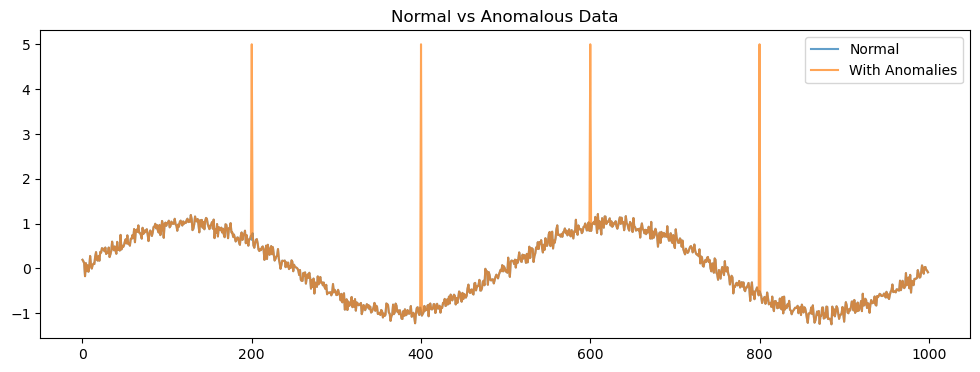

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

# Generate normal data — sine wave with small noise
t = torch.linspace(0, 4 * np.pi, 1000)
normal_data = torch.sin(t) + 0.1 * torch.randn(1000)

# Create anomalies — inject spikes at random positions
anomaly_data = normal_data.clone()
anomaly_indices = [200, 400, 600, 800]
for idx in anomaly_indices:
    anomaly_data[idx] = 5.0  # massive spike

# Plot both
plt.figure(figsize=(12, 4))
plt.plot(normal_data.numpy(), label="Normal", alpha=0.7)
plt.plot(anomaly_data.numpy(), label="With Anomalies", alpha=0.7)
plt.legend()
plt.title("Normal vs Anomalous Data")
plt.show()

In [2]:
# Create windows of size 10
window_size = 10

def create_windows(data, window_size):
    windows = []
    for i in range(len(data) - window_size):
        windows.append(data[i:i+window_size])
    return torch.stack(windows)

# Normal windows for training
X_train = create_windows(normal_data, window_size)
print(f"Training data shape: {X_train.shape}")

# Anomaly windows for testing
X_test = create_windows(anomaly_data, window_size)
print(f"Test data shape: {X_test.shape}")

Training data shape: torch.Size([990, 10])
Test data shape: torch.Size([990, 10])


In [3]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder(input_dim=window_size, latent_dim=3)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train
epochs = 200
for epoch in range(epochs):
    reconstructed = model(X_train)
    loss = loss_fn(reconstructed, X_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

Epoch 0 | Loss: 0.525616
Epoch 20 | Loss: 0.473797
Epoch 40 | Loss: 0.345306
Epoch 60 | Loss: 0.219463
Epoch 80 | Loss: 0.156667
Epoch 100 | Loss: 0.113744
Epoch 120 | Loss: 0.082515
Epoch 140 | Loss: 0.058695
Epoch 160 | Loss: 0.039909
Epoch 180 | Loss: 0.026875


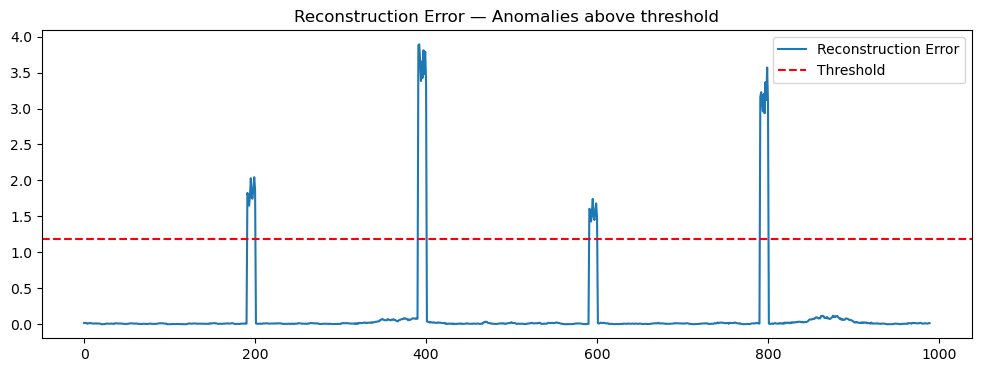

Anomalies detected: 40
Expected: 4


In [4]:
model.eval()
with torch.no_grad():
    reconstructed = model(X_test)
    errors = torch.mean((X_test - reconstructed) ** 2, dim=1)

threshold = errors.mean() + 2 * errors.std()
anomalies = errors > threshold

# Plot reconstruction error
plt.figure(figsize=(12, 4))
plt.plot(errors.numpy(), label="Reconstruction Error")
plt.axhline(y=threshold.item(), color='r', linestyle='--', label="Threshold")
plt.legend()
plt.title("Reconstruction Error — Anomalies above threshold")
plt.savefig("reconstruction_error.png")
plt.show()

print(f"Anomalies detected: {anomalies.sum().item()}")
print(f"Expected: {len(anomaly_indices)}")

In [5]:
threshold = errors.mean() + 3 * errors.std()
anomalies = errors > threshold
print(f"Anomalies detected: {anomalies.sum().item()}")

Anomalies detected: 30


In [6]:
threshold = errors.mean() + 4 * errors.std()
anomalies = errors > threshold
print(f"Anomalies detected: {anomalies.sum().item()}")

Anomalies detected: 20


In [7]:
threshold = errors.mean() + 5 * errors.std()
anomalies = errors > threshold
print(f"Anomalies detected: {anomalies.sum().item()}")

Anomalies detected: 20


In [8]:
threshold = errors.mean() + 6 * errors.std()
anomalies = errors > threshold
print(f"Anomalies detected: {anomalies.sum().item()}")

Anomalies detected: 12


In [9]:
# Find which positions were flagged
anomaly_positions = torch.where(anomalies)[0]
print(f"Flagged positions: {anomaly_positions[:20]}")
print(f"\nExpected spike positions: {anomaly_indices}")

Flagged positions: tensor([391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 797, 799])

Expected spike positions: [200, 400, 600, 800]


In [10]:
epochs = 500
for epoch in range(epochs):
    reconstructed = model(X_train)
    loss = loss_fn(reconstructed, X_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

Epoch 0 | Loss: 0.019117


Epoch 50 | Loss: 0.011938
Epoch 100 | Loss: 0.010349
Epoch 150 | Loss: 0.009857
Epoch 200 | Loss: 0.009622
Epoch 250 | Loss: 0.009462
Epoch 300 | Loss: 0.009312
Epoch 350 | Loss: 0.009146
Epoch 400 | Loss: 0.008953
Epoch 450 | Loss: 0.008738


In [11]:
for idx in anomaly_indices:
    anomaly_data[idx] = 10.0  # bigger spike

In [12]:
model.eval()
with torch.no_grad():
    reconstructed = model(X_test)
    errors = torch.mean((X_test - reconstructed) ** 2, dim=1)

threshold = errors.mean() + 3 * errors.std()
anomalies = errors > threshold

anomaly_positions = torch.where(anomalies)[0]
print(f"Anomalies detected: {anomalies.sum().item()}")
print(f"Flagged positions: {anomaly_positions}")
print(f"Expected spike positions: {anomaly_indices}")

Anomalies detected: 29
Flagged positions: tensor([192, 193, 194, 195, 196, 197, 198, 199, 391, 392, 393, 394, 395, 396,
        397, 398, 399, 400, 592, 791, 792, 793, 794, 795, 796, 797, 798, 799,
        800])
Expected spike positions: [200, 400, 600, 800]
